The objective of this project is to analyse electricity demand, generation sources and carbon intensity in Great Britain, identify key drivers of emissions, and build a model capable of forecasting electricity demand.

In [1]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("../data/cleaned_energy_data.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df.head()

,datetime,demand_mw,GAS,COAL,WIND,SOLAR,NUCLEAR,HYDRO,BIOMASS,IMPORTS,CARBON_INTENSITY,renewables_mw,fossil_mw,total_supply
0,2026-03-01 00:00:00,24829.0,4580.0,0.0,8624.0,0.0,3981.0,654,2273.0,6146.0,107.0,11551.0,4580.0,26258.0
1,2026-03-01 01:00:00,24347.5,3749.0,0.0,10087.0,0.0,3977.0,503,2269.0,5330.0,84.0,12859.0,3749.0,25915.0
2,2026-03-01 02:00:00,22791.0,2725.0,0.0,10415.0,0.0,3975.0,498,2072.0,4214.0,72.0,12985.0,2725.0,23899.0
3,2026-03-01 03:00:00,21853.5,2550.0,0.0,11987.0,0.0,3972.0,472,1150.0,3460.0,61.0,13609.0,2550.0,23591.0
4,2026-03-01 04:00:00,21067.0,2537.0,0.0,13023.0,0.0,3967.0,467,1146.0,2984.0,50.0,14636.0,2537.0,24124.0


In [8]:
print("Missing:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())

Missing: 0
Duplicates: 0


In [9]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

In [10]:
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

In [11]:
target = "demand_mw"

features = [
    "hour_sin", "hour_cos",
    "is_weekend",
    "fossil_mw",
    "renewables_mw",
    "NUCLEAR",
    "IMPORTS",
    "CARBON_INTENSITY"
]

X = df[features]
y = df[target]

In [12]:
split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

The cleaned dataset was loaded and briefly validated to confirm the absence of missing values and duplicates.

Feature engineering was then performed to extract time-based and energy mix variables relevant for predicting electricity demand. A time-based split was used to separate training and testing data, ensuring that the model is evaluated on future observations.

## Model: Random Forest

Random Forest is used because:
- handles non-linear relationships well
- robust to noise
- does not require scaling

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1589.384603174603
RMSE: 2110.815012592039
R²: 0.687115076793282


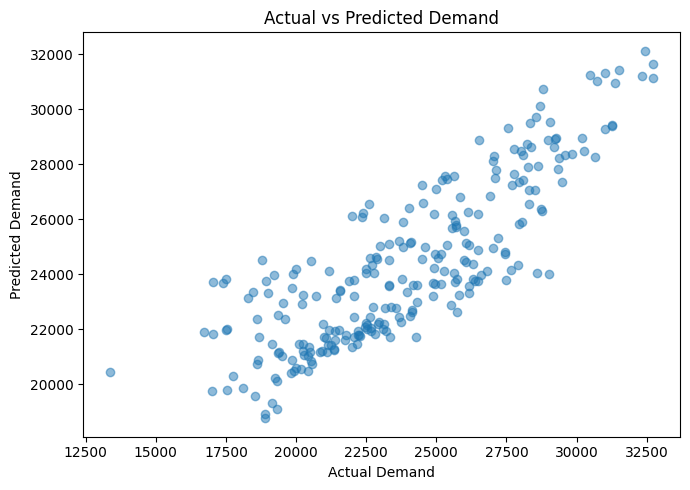

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.tight_layout()
plt.show()

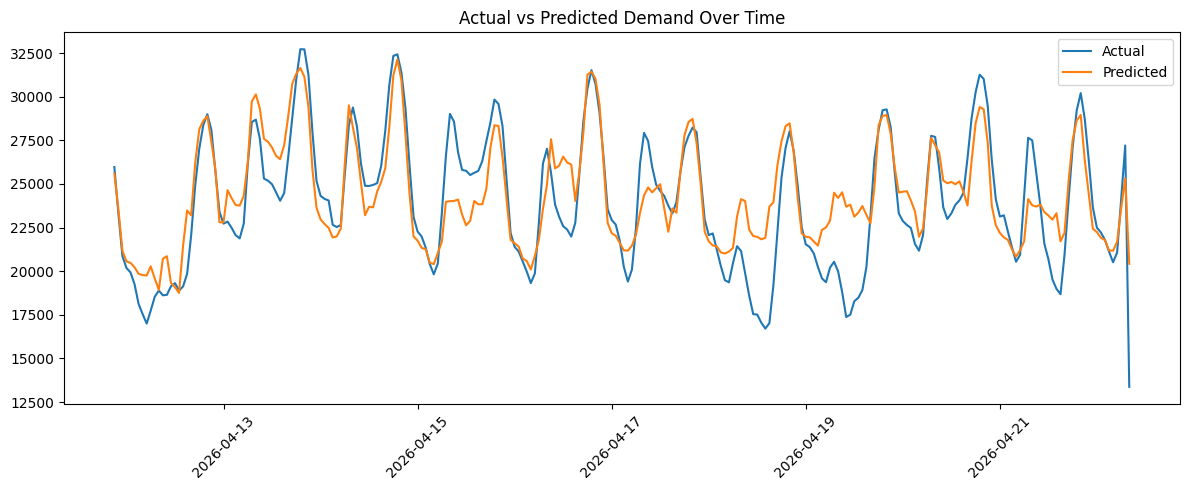

In [17]:
plt.figure(figsize=(12,5))

plt.plot(df['datetime'].iloc[split:], y_test.values, label="Actual")
plt.plot(df['datetime'].iloc[split:], y_pred, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Demand Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:


importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

importance

fossil_mw           0.360339
hour_sin            0.237064
NUCLEAR             0.128513
IMPORTS             0.098205
hour_cos            0.060999
renewables_mw       0.051799
CARBON_INTENSITY    0.041868
is_weekend          0.021214
dtype: float64

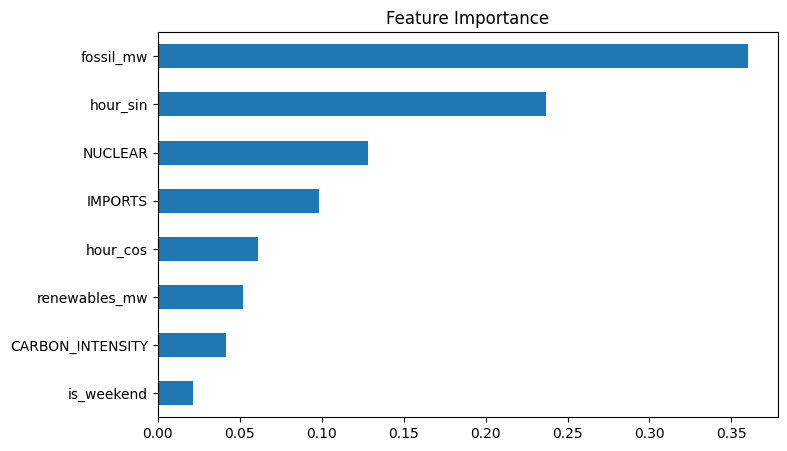

In [19]:
importance.plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Interpretation

The model shows that time-based features and energy mix variables play a significant role in predicting electricity demand.

In particular:
- Hour-based features capture daily demand cycles
- Fossil and renewable generation reflect system response to demand
- Imports and nuclear provide additional system context

This confirms that electricity demand is driven by both temporal patterns and system-level energy dynamics.

## Model Selection

A Random Forest regressor was selected as the primary model for this analysis.

This choice was motivated by the nature of the dataset, which contains complex and non-linear relationships between electricity demand and predictor variables such as time features and energy generation mix.

Unlike linear models, Random Forest is capable of capturing non-linear interactions without requiring explicit feature transformations. Additionally, it is robust to noise and reduces the risk of overfitting by averaging multiple decision trees.

Random Forest is also well-suited for tabular data and does not require feature scaling, simplifying the modelling pipeline.

Importantly, the model provides feature importance metrics, enabling interpretability and allowing insights into the key drivers of electricity demand.

Overall, Random Forest offers a strong balance between predictive performance and interpretability, making it an appropriate choice for this problem.

## Model 2: Gradient Boosting Regressor

Gradient Boosting is used as an improved ensemble model.

Unlike Random Forest, which builds trees independently, Gradient Boosting builds trees sequentially. Each new tree attempts to correct the errors made by the previous trees.

This makes Gradient Boosting useful for capturing complex patterns in structured data such as energy demand.


In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

Gradient Boosting Results
MAE: 1517.4291094871817
RMSE: 2064.6876935244036
R²: 0.7006405127222445


In [23]:
mae_rf = mean_absolute_error(y_test, y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))
r2_rf = r2_score(y_test, y_pred)

results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "MAE": [mae_rf, mae_gb],
    "RMSE": [rmse_rf, rmse_gb],
    "R²": [r2_rf, r2_gb]
})

results

,Model,MAE,RMSE,R²
0,Random Forest,1589.384603,2110.815013,0.687115
1,Gradient Boosting,1517.429109,2064.687694,0.700641


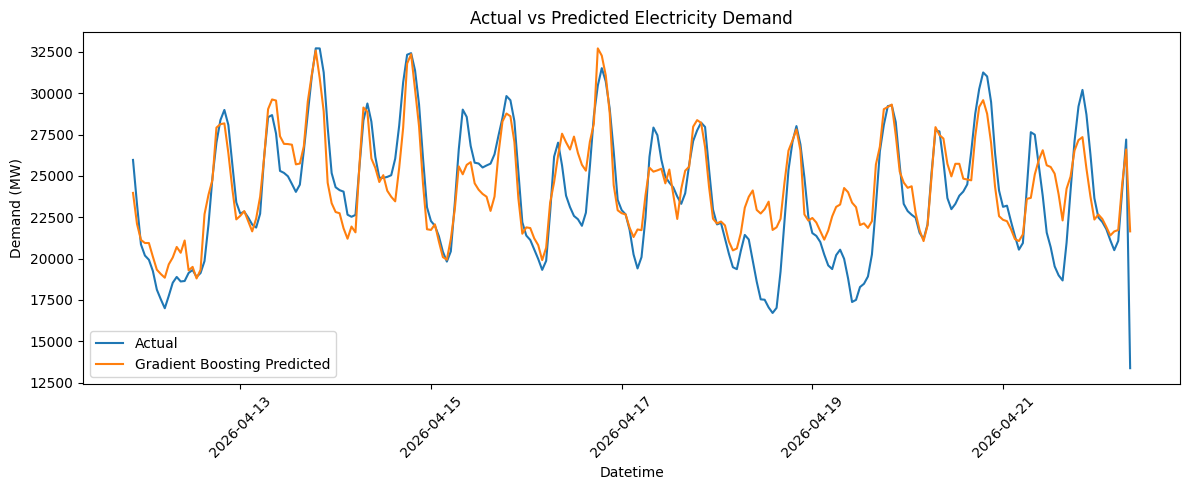

In [24]:
plt.figure(figsize=(12,5))

plt.plot(df["datetime"].iloc[split:], y_test.values, label="Actual")
plt.plot(df["datetime"].iloc[split:], y_pred_gb, label="Gradient Boosting Predicted")

plt.title("Actual vs Predicted Electricity Demand")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
gb_importance = pd.Series(
    gb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

gb_importance

fossil_mw           0.369767
hour_sin            0.226144
NUCLEAR             0.135906
hour_cos            0.093604
IMPORTS             0.074807
CARBON_INTENSITY    0.036481
renewables_mw       0.032653
is_weekend          0.030637
dtype: float64

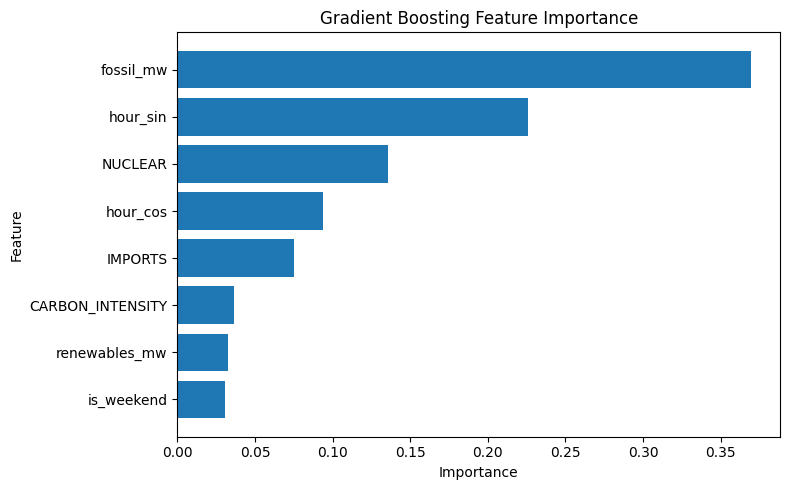

In [26]:
plt.figure(figsize=(8,5))
plt.barh(gb_importance.index, gb_importance.values)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model Performance Evaluation

The performance of Random Forest and Gradient Boosting models was compared using MAE, RMSE and R².

The results show that Gradient Boosting outperforms Random Forest across all evaluation metrics:

- MAE decreased from 1589 MW to 1517 MW
- RMSE decreased from 2110 MW to 2064 MW
- R² increased from 0.687 to 0.701

This indicates that Gradient Boosting provides more accurate and consistent predictions of electricity demand.

Although the improvement is moderate, it demonstrates the benefit of sequential learning, where Gradient Boosting iteratively corrects errors from previous trees.

An R² value of approximately 0.70 suggests that the model captures a significant portion of demand variability, although some variation remains unexplained. This is expected, as electricity demand is influenced by additional external factors such as weather conditions and behavioural patterns that are not included in the dataset.

Overall, Gradient Boosting was selected as the final model due to its superior performance.The results highlight that while machine learning models can effectively capture general demand patterns, incorporating additional features such as weather data could further improve predictive performance.

In [27]:
improvement = (rmse_rf - rmse_gb) / rmse_rf * 100
print(f"RMSE improvement: {improvement:.2f}%")

RMSE improvement: 2.19%
